In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import files
files.upload()

{}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d msambare/fer2013
!unzip -o fer2013.zip -d /content

Streaming output truncated to the last 5000 lines.
  inflating: /content/train/sad/Training_65242339.jpg  
  inflating: /content/train/sad/Training_65267116.jpg  
  inflating: /content/train/sad/Training_65275626.jpg  
  inflating: /content/train/sad/Training_6529266.jpg  
  inflating: /content/train/sad/Training_65329617.jpg  
  inflating: /content/train/sad/Training_65338712.jpg  
  inflating: /content/train/sad/Training_65338797.jpg  
  inflating: /content/train/sad/Training_65387162.jpg  
  inflating: /content/train/sad/Training_65404494.jpg  
  inflating: /content/train/sad/Training_65426218.jpg  
  inflating: /content/train/sad/Training_65430136.jpg  
  inflating: /content/train/sad/Training_65437377.jpg  
  inflating: /content/train/sad/Training_6545735.jpg  
  inflating: /content/train/sad/Training_65463385.jpg  
  inflating: /content/train/sad/Training_65473985.jpg  
  inflating: /content/train/sad/Training_65502829.jpg  
  inflating: /content/train/sad/Training_65505359.jpg  

In [ ]:
import os
import numpy as np
import pandas as pd
import math

import seaborn as sns
from matplotlib import pyplot

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import optimizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Conv2D, MaxPooling2D
from tensorflow.keras.layers import Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical, load_img, img_to_array

In [ ]:
emotion = {'happy', 'sad', 'neutral'}

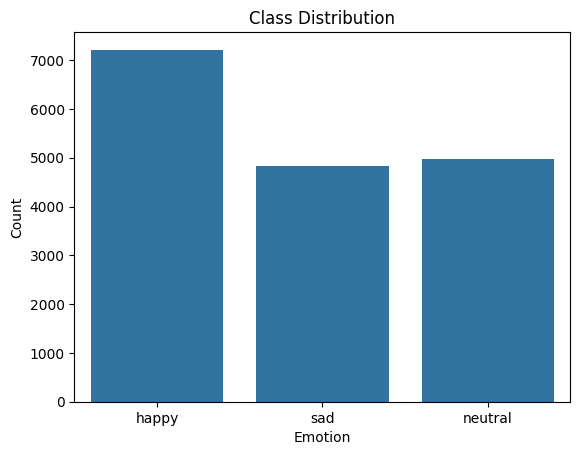

classes:
  happy: 7215 images
  sad: 4830 images
  neutral: 4965 images


In [ ]:
# توزيع الـ classes
class_counts = {}
for label_name in emotion:
    folder = os.path.join('/content/train', label_name)
    class_counts[label_name] = len(os.listdir(folder))

sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()))
pyplot.title('Class Distribution')
pyplot.xlabel('Emotion')
pyplot.ylabel('Count')
pyplot.show()

print("classes:")
for name, count in class_counts.items():
    print(f"  {name}: {count} images")

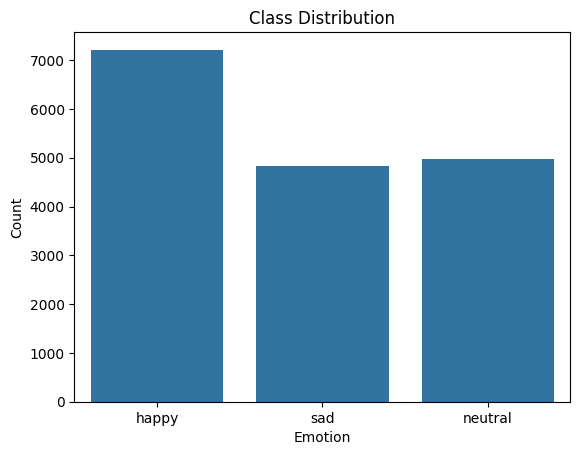

classes:
  happy: 7215 images
  sad: 4830 images
  neutral: 4965 images


In [ ]:
INTERESTED = ['happy', 'sad', 'neutral']
label_map  = {'happy': 0, 'sad': 1, 'neutral': 2}

#classes
class_counts = {}
for label_name in INTERESTED:
    folder = os.path.join('/content/train', label_name)
    class_counts[label_name] = len(os.listdir(folder))

sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()))
pyplot.title('Class Distribution')
pyplot.xlabel('Emotion')
pyplot.ylabel('Count')
pyplot.show()

print("classes:")
for name, count in class_counts.items():
    print(f"  {name}: {count} images")

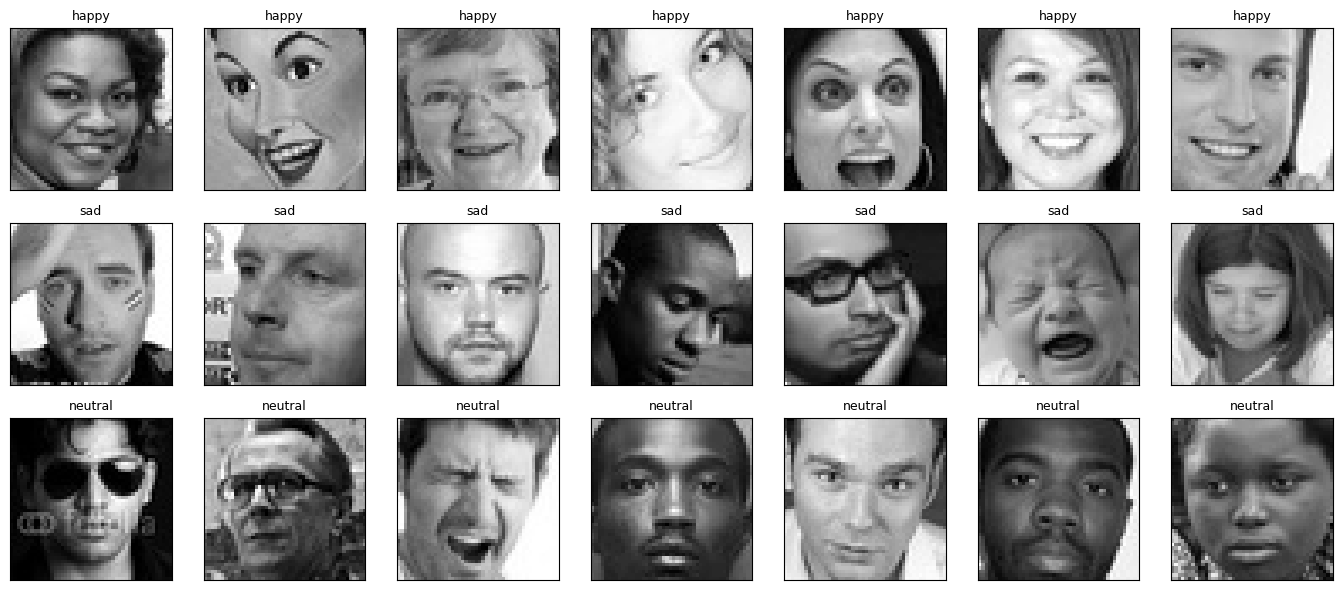

In [ ]:
fig = pyplot.figure(1, (14, 6))
k = 0
for label_name in INTERESTED:
    folder = os.path.join('/content/train', label_name)
    files  = os.listdir(folder)[:7]
    for fname in files:
        img = load_img(os.path.join(folder, fname),
                       color_mode='grayscale',
                       target_size=(48, 48))
        k += 1
        ax = pyplot.subplot(3, 7, k)
        ax.imshow(img_to_array(img).squeeze(), cmap='gray')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(label_name, fontsize=9)
        pyplot.tight_layout()
pyplot.show()

In [ ]:
print(os.listdir('/content'))

['.config', 'drive', 'test', 'train', 'fer2013.zip', 'sample_data']


In [ ]:
def load_from_folder(base_path):
    images, labels = [], []
    for label_name in INTERESTED:
        folder = os.path.join(base_path, label_name)
        for fname in os.listdir(folder):
            if fname.endswith(('.png', '.jpg')):
                img = load_img(os.path.join(folder, fname),
                               color_mode='grayscale',
                               target_size=(48, 48))
                images.append(img_to_array(img))
                labels.append(label_map[label_name])
    return np.array(images), np.array(labels)

# تحميل الصور الأصلية
img_original, labels_original = load_from_folder('/content/train')
labels_original = to_categorical(labels_original, num_classes=3)

# تحميل الصور المولّدة من GAN
img_gan    = np.load("/content/drive/MyDrive/gan_generated_images.npy")
labels_gan = np.load("/content/drive/MyDrive/gan_generated_labels.npy")
labels_gan = to_categorical(labels_gan, num_classes=3)

# دمج الاتنين
img_train    = np.concatenate([img_original, img_gan], axis=0)
labels_train = np.concatenate([labels_original, labels_gan], axis=0)

print(f"Total train: {img_train.shape}")

# الـ test بيفضل أصلي عشان التقييم يكون حقيقي
X_test, labels_test = load_from_folder('/content/test')
y_test = to_categorical(labels_test, num_classes=3)
print(f"Train: {img_train.shape}")
print(f"Test:  {X_test.shape}")

Total train: (34020, 48, 48, 1)
Train: (34020, 48, 48, 1)
Test:  (4254, 48, 48, 1)


In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(
    img_train, labels_train,
    test_size=0.10,
    random_state=42,
   stratify=np.argmax(labels_train, axis=1)
)

del img_train, labels_train

print(f"Train:      {X_train.shape}")
print(f"Validation: {X_valid.shape}")
print(f"Test:       {X_test.shape}")

Train:      (30618, 48, 48, 1)
Validation: (3402, 48, 48, 1)
Test:       (4254, 48, 48, 1)


In [ ]:
X_train = X_train / 255.
X_valid  = X_valid  / 255.
X_test   = X_test   / 255.

img_width   = X_train.shape[1]
img_height  = X_train.shape[2]
img_depth   = X_train.shape[3]
num_classes = y_train.shape[1]

print(f"Image size: {img_width}x{img_height}x{img_depth}")
print(f"Num classes: {num_classes}")

Image size: 48x48x1
Num classes: 3


In [ ]:
def build_net(optim):
    net = Sequential(name='DCNN')

    net.add(Conv2D(64, (5,5), input_shape=(img_width, img_height, img_depth),
                   activation='elu', padding='same',
                   kernel_initializer='he_normal'))
    net.add(BatchNormalization())
    net.add(Conv2D(64, (5,5), activation='elu', padding='same',
                   kernel_initializer='he_normal'))
    net.add(BatchNormalization())
    net.add(MaxPooling2D(pool_size=(2,2)))
    net.add(Dropout(0.4))

    net.add(Conv2D(128, (3,3), activation='elu', padding='same',
                   kernel_initializer='he_normal'))
    net.add(BatchNormalization())
    net.add(Conv2D(128, (3,3), activation='elu', padding='same',
                   kernel_initializer='he_normal'))
    net.add(BatchNormalization())
    net.add(MaxPooling2D(pool_size=(2,2)))
    net.add(Dropout(0.4))

    net.add(Conv2D(256, (3,3), activation='elu', padding='same',
                   kernel_initializer='he_normal'))
    net.add(BatchNormalization())
    net.add(Conv2D(256, (3,3), activation='elu', padding='same',
                   kernel_initializer='he_normal'))
    net.add(BatchNormalization())
    net.add(MaxPooling2D(pool_size=(2,2)))
    net.add(Dropout(0.5))

    net.add(Flatten())
    net.add(Dense(128, activation='elu', kernel_initializer='he_normal'))
    net.add(BatchNormalization())
    net.add(Dropout(0.6))
    net.add(Dense(num_classes, activation='softmax'))

    net.compile(
    loss='categorical_crossentropy',
    optimizer=optim,
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision', thresholds=0.5),
        tf.keras.metrics.Recall(name='recall', thresholds=0.5),
    ]
)

    net.summary()
    return net

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        min_delta=0.00005,
        patience=11,
        verbose=1,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.5,
        patience=7,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
]

# Augmentation كـ function مش generator
def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
    return image, label

In [ ]:
batch_size = 32
epochs     = 100

model = build_net(optimizers.Adam(learning_rate=0.001))

train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_dataset = (train_dataset
                 .shuffle(buffer_size=len(X_train), seed=42)
                 .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
                 .batch(batch_size)
                 .repeat()
                 .prefetch(tf.data.AUTOTUNE))

history = model.fit(
    train_dataset,
    validation_data=(X_valid, y_valid),
    steps_per_epoch=len(X_train) // batch_size,
    epochs=epochs,
    callbacks=callbacks
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "DCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,395,075 (9.14 MB)

 Trainable params: 2,393,027 (9.13 MB)

 Non-trainable params: 2,048 (8.00 KB)

Epoch 1/100
956/956 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3636 - loss: 1.4630 - precision: 0.3697 - recall: 0.2530
Epoch 1: val_accuracy improved from None to 0.48119, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
956/956 ━━━━━━━━━━━━━━━━━━━━ 45s 30ms/step - accuracy: 0.3948 - loss: 1.2421 - precision: 0.4166 - recall: 0.2201 - val_accuracy: 0.4812 - val_loss: 1.0544 - val_precision: 0.8913 - val_recall: 0.0241 - learning_rate: 0.0010
Epoch 2/100
955/956 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.4760 - loss: 1.0138 - precision: 0.5956 - recall: 0.2214
Epoch 2: val_accuracy improved from 0.48119 to 0.51529, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
956/956 ━━━━━━━━━━━━━━━━━━━━ 32s 25ms/step - accuracy: 0.4881 - loss: 0.9930 - precision: 0.6190 - recall: 0.2369 - val_accuracy: 0.5153 - val_loss: 0.9549 - val_precision: 0.7029 - val_recall: 0.2393 - learning_rate: 0.0010
Epoch 3/100
955/956 ━

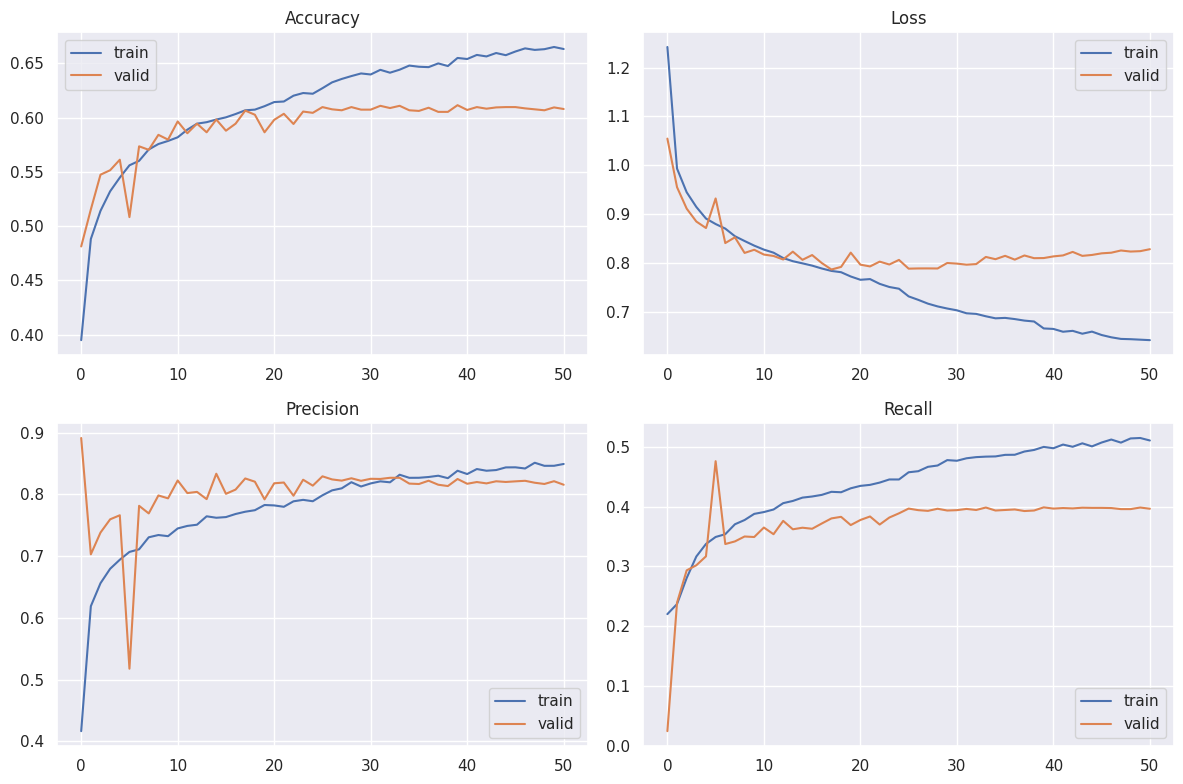

In [ ]:
sns.set()
fig = pyplot.figure(0, (12, 8))

# Accuracy
ax = pyplot.subplot(2, 2, 1)
sns.lineplot(x=history.epoch, y=history.history['accuracy'], label='train')
sns.lineplot(x=history.epoch, y=history.history['val_accuracy'], label='valid')
pyplot.title('Accuracy')

# Loss
ax = pyplot.subplot(2, 2, 2)
sns.lineplot(x=history.epoch, y=history.history['loss'], label='train')
sns.lineplot(x=history.epoch, y=history.history['val_loss'], label='valid')
pyplot.title('Loss')

# Precision
ax = pyplot.subplot(2, 2, 3)
sns.lineplot(x=history.epoch, y=history.history['precision'], label='train')
sns.lineplot(x=history.epoch, y=history.history['val_precision'], label='valid')
pyplot.title('Precision')

# Recall
ax = pyplot.subplot(2, 2, 4)
sns.lineplot(x=history.epoch, y=history.history['recall'], label='train')
sns.lineplot(x=history.epoch, y=history.history['val_recall'], label='valid')
pyplot.title('Recall')

pyplot.tight_layout()
pyplot.savefig('training_history.png')
pyplot.show()

133/133 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.7026 - loss: 13.5813 - precision: 0.7028 - recall: 0.7026

Test Loss:      13.5813
Test Accuracy:  0.7026
Test Precision: 0.7028
Test Recall:    0.7026
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step


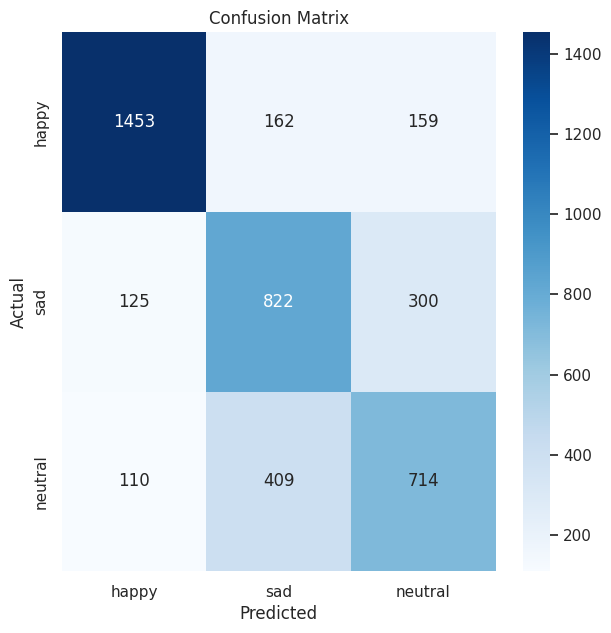

              precision    recall  f1-score   support

       happy       0.86      0.82      0.84      1774
         sad       0.59      0.66      0.62      1247
     neutral       0.61      0.58      0.59      1233

    accuracy                           0.70      4254
   macro avg       0.69      0.69      0.69      4254
weighted avg       0.71      0.70      0.70      4254



In [ ]:
test_loss, test_accuracy, test_precision, test_recall = model.evaluate(
    X_test, y_test, verbose=1
)
print(f"\nTest Loss:      {test_loss:.4f}")
print(f"Test Accuracy:  {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall:    {test_recall:.4f}")

yhat_test = np.argmax(model.predict(X_test), axis=1)
y_true    = np.argmax(y_test, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, yhat_test)
pyplot.figure(figsize=(7, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['happy', 'sad', 'neutral'],
            yticklabels=['happy', 'sad', 'neutral'])
pyplot.ylabel('Actual')
pyplot.xlabel('Predicted')
pyplot.title('Confusion Matrix')
pyplot.savefig('confusion_matrix.png')
pyplot.show()

# Classification Report
print(classification_report(y_true, yhat_test,
      target_names=['happy', 'sad', 'neutral']))

In [ ]:
from tensorflow.keras.models import load_model

best_model = load_model('best_model.keras')

best_loss, best_accuracy, best_precision, best_recall = best_model.evaluate(
    X_test, y_test, verbose=1
)
print(f"\nBest Model — Test Accuracy:  {best_accuracy:.4f}")
print(f"Best Model — Test Precision: {best_precision:.4f}")
print(f"Best Model — Test Recall:    {best_recall:.4f}")

133/133 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7026 - loss: 13.5813 - precision: 0.7028 - recall: 0.7026

Best Model — Test Accuracy:  0.7026
Best Model — Test Precision: 0.7028
Best Model — Test Recall:    0.7026


In [ ]:
model.save("final_model.keras")
print("Final model saved.")

Final model saved.


In [ ]:
from google.colab import files
files.download("final_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>